# Lock primitives across x86_64 and aarch64 — cross-platform analysis

**Goal.** Compare seven lock primitives on three concurrent indexes (wormhole, libcds StripedMap, libcds BronsonAVL) across two server architectures — Intel Xeon E5-2650L v3 (Haswell-EP, 2014) and AWS Graviton2 (Neoverse N1, 2020) — and **explain the cross-platform performance differences in terms of the underlying microarchitecture**.

**Architecturally relevant differences between the two platforms** (these will be referenced repeatedly):

| Property | Xeon E5-2650L v3 | Graviton2 (c6g/c7g) |
| --- | --- | --- |
| ISA / atomic flavour | x86_64 with **LOCK-prefix** RMW (one round-trip on the bus per RMW) | aarch64 with **LSE atomics** (single-instruction atomics introduced in ARMv8.1) |
| Microarchitecture | Haswell-EP (2014) | Neoverse N1 (2020) |
| Base clock | 1.8 GHz | 2.5 GHz |
| Memory model | TSO (total store order, strong) | weakly ordered (release/acquire by default) |
| Cores tested (single-socket cap) | 12 P-cores, one socket | 8 physical cores, one socket |
| DRAM | DDR4-2133 | DDR4-3200 |
| Last-level cache | 30 MB shared L3 | 32 MB shared L3 |

**Methodology summary** (see `docs/INDEX_LOCK_DECISIONS.md` D1–D23 for the full log):
- Two-phase timed loop with strided `stop` check (D3, D4); pre-rolled `(key, op)` streams (D22) — workload generation removed from the timed window.
- `compact_phys` pinning (D1, D2) — one logical thread per physical core (no SMT confounds; no sudo required).
- Single-socket cap (D23) so cross-socket coherence cost doesn't confound the lock-vs-lock story.
- 12-cell cache-regime matrix (D11, D21): L1-resident (1k keys) and L3-resident (100k keys) × uniform / zipfian θ=0.99 / 1.2 / 1.5 × 90/5/5 vs 50/25/25 mixes.
- 5 s × 3 repeats per cell (D19, D23). Numbers are medians of 3 trials with IQR error bars.


## 0. Setup and data loading

Load all six CSVs (two arches × three benches), parse the European-decimal-comma fields, and derive workload-shape labels (`cache_regime`, `skew_tier`, `mix`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'font.size': 10,
})

REPO_ROOT = Path('..').resolve() if Path('..').joinpath('CMakeLists.txt').exists() else Path('.').resolve()
print(f'repo: {REPO_ROOT}')

# Per-lock visual style.
LOCK_STYLE = {
    'wh-default':  dict(color='#666666', marker='o', label='wh-default (counter rwlock)'),
    'wh-tas':      dict(color='#d62728', marker='s', label='wh-tas (spinlock-as-rwlock)'),
    'wh-ttas':     dict(color='#ff7f0e', marker='^', label='wh-ttas'),
    'wh-cas':      dict(color='#bcbd22', marker='D', label='wh-cas'),
    'wh-occ':      dict(color='#9467bd', marker='v', label='wh-occ (seqlock write-side)'),
    'wh-occ-opt':  dict(color='#8c564b', marker='*', label='wh-occ-opt (lock-free reads)'),
    'wh-pcpu-rw':  dict(color='#2ca02c', marker='P', label='wh-pcpu-rw (per-CPU rwlock)'),
    'cds-std':     dict(color='#666666', marker='o', label='cds-std (pthread mutex)'),
    'cds-tas':     dict(color='#d62728', marker='s', label='cds-tas'),
    'cds-ttas':    dict(color='#ff7f0e', marker='^', label='cds-ttas'),
    'cds-cas':     dict(color='#bcbd22', marker='D', label='cds-cas'),
    'cds-ticket':  dict(color='#17becf', marker='X', label='cds-ticket'),
    'avl-std':     dict(color='#666666', marker='o', label='avl-std'),
    'avl-tas':     dict(color='#d62728', marker='s', label='avl-tas'),
    'avl-ttas':    dict(color='#ff7f0e', marker='^', label='avl-ttas'),
    'avl-cas':     dict(color='#bcbd22', marker='D', label='avl-cas'),
    'avl-ticket':  dict(color='#17becf', marker='X', label='avl-ticket'),
}
ARCH_LABEL = {'x86_64': 'Xeon E5-2650L v3', 'aarch64': 'Graviton2'}
ARCH_COLOR = {'x86_64': '#1f77b4', 'aarch64': '#ff7f0e'}

repo: /Users/andreipana/Desktop/Research Project/lockbench


In [2]:
def _to_float(s):
    if pd.isna(s) or s == '': return np.nan
    if isinstance(s, (int, float, np.floating, np.integer)): return float(s)
    return float(str(s).replace(',', '.'))

def load_csv(path):
    df = pd.read_csv(path, sep=';')
    for col in ('zipf_theta', 'ns_op', 'fairness_ratio'):
        if col in df.columns:
            df[col] = df[col].apply(_to_float)
    return df

def load_all():
    frames = []
    for arch in ('x86_64', 'aarch64'):
        for bench, suffix in (('wh', 'wh_compare/wh.csv'),
                              ('cds', 'cdsbench/cdsbench.csv'),
                              ('avl', 'avl_compare/cds_avl.csv')):
            p = REPO_ROOT / 'results' / arch / suffix
            if not p.exists():
                print(f'  skip (not found): {p}')
                continue
            df = load_csv(p)
            df['bench'] = bench
            if 'arch' not in df.columns: df['arch'] = arch
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

def derive_labels(df):
    kr = df['key_range'].astype(int)
    df['cache_regime'] = np.where(kr <= 10_000, 'L1',
                          np.where(kr <= 500_000, 'L3', 'DRAM'))
    def _skew(row):
        if row['dist'] == 'uniform': return 'uniform'
        t = row['zipf_theta']
        if t < 1.0: return 'warm'
        if t < 1.4: return 'hot'
        return 'extreme'
    df['skew_tier'] = df.apply(_skew, axis=1)
    rd = df['read_pct'].astype(int)
    df['mix'] = np.where(rd >= 90, 'read_heavy', 'write_heavy')
    df['workload'] = df['cache_regime'] + '_' + df['skew_tier'] + '_' + df['mix']
    return df

def aggregate(df):
    keys = ['arch', 'bench', 'lock', 'workload', 'cache_regime', 'skew_tier', 'mix',
            'key_range', 'zipf_theta', 'read_pct', 'insert_pct', 'threads',
            'stream_len', 'buckets']
    keys = [k for k in keys if k in df.columns]
    agg = (df.groupby(keys, dropna=False)
             .agg(ops_s_median=('ops_s', 'median'),
                  ops_s_p25=('ops_s', lambda s: np.percentile(s, 25)),
                  ops_s_p75=('ops_s', lambda s: np.percentile(s, 75)),
                  ns_op_median=('ns_op', 'median'),
                  fairness_median=('fairness_ratio', 'median'),
                  n=('ops_s', 'count'))
             .reset_index())
    return agg

In [3]:
raw = derive_labels(load_all())
agg = aggregate(raw)
print(f'raw rows: {len(raw):,}  agg rows: {len(agg):,}')
print(f'archs: {sorted(raw.arch.unique())}')
print(f'benches: {sorted(raw.bench.unique())}')
print(f'locks: {sorted(raw.lock.unique())}')
print(f'unique workloads: {sorted(raw.workload.unique())}')
print(f'threads: x86_64 → {sorted(raw[raw.arch == "x86_64"].threads.unique())},  aarch64 → {sorted(raw[raw.arch == "aarch64"].threads.unique())}')

raw rows: 5,751  agg rows: 1,917
archs: ['aarch64', 'x86_64']
benches: ['avl', 'cds', 'wh']
locks: ['avl-cas', 'avl-std', 'avl-tas', 'avl-ticket', 'avl-ttas', 'cds-cas', 'cds-std', 'cds-tas', 'cds-ticket', 'cds-ttas', 'wh-cas', 'wh-default', 'wh-occ', 'wh-occ-opt', 'wh-pcpu-rw', 'wh-tas', 'wh-ttas']
unique workloads: ['DRAM_uniform_write_heavy', 'L1_extreme_read_heavy', 'L1_hot_read_heavy', 'L1_uniform_read_heavy', 'L1_uniform_write_heavy', 'L1_warm_read_heavy', 'L1_warm_write_heavy', 'L3_extreme_read_heavy', 'L3_hot_read_heavy', 'L3_uniform_read_heavy', 'L3_uniform_write_heavy', 'L3_warm_read_heavy', 'L3_warm_write_heavy']
threads: x86_64 → [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(12)],  aarch64 → [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]


## 1. Measurement quality

Coefficient of variation across the three trials, by (arch × bench). Anything > 10 % gets flagged. **Spoiler**: most of the high-CoV cells turn out to be the per-CPU rwlock (`wh-pcpu-rw`) at high thread counts. The lock isn't broken on either platform individually — its *non-deterministic collapse mode* under contention is the source of the variance (see §6).

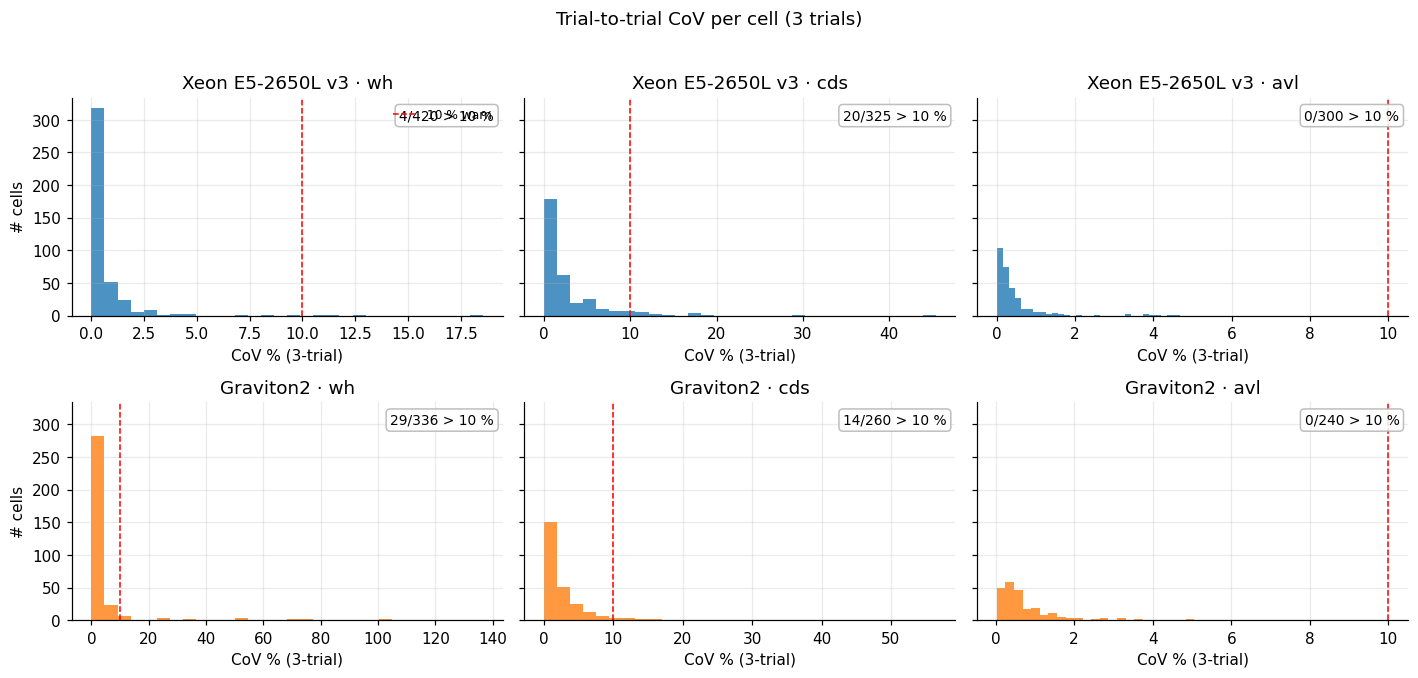


Highest-CoV cells (all archs, all benches):
  CoV=136.6%  aarch64  wh-pcpu-rw   L1_extreme_read_heavy            threads=8
  CoV=104.2%  aarch64  wh-pcpu-rw   L1_hot_read_heavy                threads=4
  CoV=101.4%  aarch64  wh-pcpu-rw   L3_hot_read_heavy                threads=4
  CoV= 83.0%  aarch64  wh-pcpu-rw   L1_extreme_read_heavy            threads=4
  CoV= 75.3%  aarch64  wh-pcpu-rw   L1_warm_write_heavy              threads=4
  CoV= 74.2%  aarch64  wh-pcpu-rw   L1_warm_read_heavy               threads=4
  CoV= 69.7%  aarch64  wh-pcpu-rw   L1_uniform_read_heavy            threads=8
  CoV= 69.3%  aarch64  wh-pcpu-rw   L1_hot_read_heavy                threads=8
  CoV= 67.2%  aarch64  wh-pcpu-rw   L3_extreme_read_heavy            threads=8
  CoV= 56.5%  aarch64  cds-ticket   DRAM_uniform_write_heavy         threads=4
  CoV= 56.2%  aarch64  wh-pcpu-rw   L3_hot_read_heavy                threads=8
  CoV= 53.7%  aarch64  wh-pcpu-rw   L1_warm_write_heavy              threads=8


In [4]:
cov = (raw.groupby(['arch', 'bench', 'lock', 'workload', 'threads'])
          .agg(mean=('ops_s', 'mean'), std=('ops_s', 'std'))
          .assign(cov_pct=lambda d: 100 * d['std'] / d['mean'])
          .reset_index())

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
for col, bench in enumerate(['wh', 'cds', 'avl']):
    for row, arch in enumerate(['x86_64', 'aarch64']):
        ax = axes[row, col]
        sub = cov[(cov.bench == bench) & (cov.arch == arch)]
        ax.hist(sub.cov_pct.dropna(), bins=30, color=ARCH_COLOR[arch], alpha=0.8)
        ax.axvline(10, color='red', linestyle='--', lw=1, label='10 % warn')
        ax.set_title(f'{ARCH_LABEL[arch]} · {bench}')
        ax.set_xlabel('CoV % (3-trial)')
        if col == 0: ax.set_ylabel('# cells')
        n_high = (sub.cov_pct > 10).sum()
        ax.text(0.98, 0.95, f'{n_high}/{len(sub)} > 10 %',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
        if row == 0 and col == 0: ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Trial-to-trial CoV per cell (3 trials)', y=1.02)
plt.tight_layout(); plt.show()

# Top-12 noisiest cells
worst = cov.sort_values('cov_pct', ascending=False).head(12)
print('\nHighest-CoV cells (all archs, all benches):')
for _, r in worst.iterrows():
    print(f"  CoV={r['cov_pct']:5.1f}%  {r['arch']:<8} {r['lock']:<12} "
          f"{r['workload']:<32} threads={int(r['threads'])}")

## 2. Cross-architecture headline

The single most useful summary: at each architecture's maximum thread count, on the lock-bound thesis workload (L1-resident, warm zipfian, 90/5/5 read-heavy), what does each lock deliver — and by what factor does the architecture matter?

Reading the table below:
- **`vs default`** is the lock's throughput relative to `wh-default` *on the same architecture* (>1 means it beats the counter-based rwlock baseline).
- **`Graviton/Xeon`** is the cross-architecture speedup: how much faster the same lock runs on the same workload at each architecture's max threads. **A value > 1 means Graviton2 is faster**.

In [5]:
# Headline cell at each arch's max threads.
headline = agg[(agg.bench == 'wh') & (agg.cache_regime == 'L1') &
               (agg.skew_tier == 'warm') & (agg.mix == 'read_heavy')]

def at_max_threads(df_arch):
    if df_arch.empty: return df_arch
    maxT = int(df_arch.threads.max())
    return df_arch[df_arch.threads == maxT]

xeon_top  = at_max_threads(headline[headline.arch == 'x86_64']).set_index('lock')
grav_top  = at_max_threads(headline[headline.arch == 'aarch64']).set_index('lock')
xeon_default = xeon_top.loc['wh-default', 'ops_s_median']
grav_default = grav_top.loc['wh-default', 'ops_s_median']

rows = []
for lk in ['wh-default', 'wh-pcpu-rw', 'wh-occ-opt', 'wh-occ', 'wh-cas', 'wh-ttas', 'wh-tas']:
    if lk not in xeon_top.index or lk not in grav_top.index: continue
    xv = float(xeon_top.loc[lk, 'ops_s_median'])
    gv = float(grav_top.loc[lk, 'ops_s_median'])
    rows.append({
        'lock': lk,
        'Xeon @ 12T (M ops/s)': round(xv / 1e6, 2),
        'Xeon vs default': round(xv / xeon_default, 2),
        'Graviton @ 8T (M ops/s)': round(gv / 1e6, 2),
        'Graviton vs default': round(gv / grav_default, 2),
        'Graviton / Xeon ratio': round(gv / xv, 2),
    })
summary = pd.DataFrame(rows)
summary

,lock,Xeon @ 12T (M ops/s),Xeon vs default,Graviton @ 8T (M ops/s),Graviton vs default,Graviton / Xeon ratio
0,wh-default,13.82,1.00,20.33,1.00,1.47
1,wh-pcpu-rw,2.47,0.18,0.03,0.00,0.01
2,wh-occ-opt,51.10,3.70,69.63,3.43,1.36
3,wh-occ,6.22,0.45,11.03,0.54,1.77
4,wh-cas,5.02,0.36,15.52,0.76,3.09
5,wh-ttas,5.04,0.36,14.52,0.71,2.88
6,wh-tas,5.09,0.37,14.23,0.70,2.80


### Reading the headline table

Three things to take away before drilling in:

1. **`wh-occ-opt` is the runaway winner on both platforms**, 3.4–3.7× faster than `wh-default` at max threads. Lock-free reads via a per-leaf seqlock skip the lock state entirely — readers don't participate in the contended cache line at all.
2. **`wh-pcpu-rw` does the opposite of what the thesis predicted**. Far from improving on the counter-based rwlock, it collapses by 5× on Xeon and by 600× on Graviton at max threads. The per-CPU rwlock's reader-retract-and-retry mechanism enters a thundering-herd regime when writers arrive frequently enough — and Graviton's faster atomics make the collapse worse, not better. (Detailed analysis in §6.)
3. **Graviton/Xeon ratios > 1 for every lock except pcpu-rw**. On the same workload at each platform's saturation point, Graviton2 is 1.4–2.8× faster than the Xeon for every counter-based or spinlock variant. This is consistent with Graviton2's modern Neoverse-N1 microarchitecture (LSE atomics, faster DRAM, 2.5 GHz vs 1.8 GHz base clock) — but the magnitude varies sharply per lock and reveals which locks are atomic-cost-bound vs scheduling-bound.


## 3. Where does the architecture matter?

Plot the cross-arch ratio (Graviton ops/s / Xeon ops/s) at matched thread counts for each lock, on the headline workload. A flat horizontal line at 1.0 = parity. **Where the ratio diverges, the architecture is doing something the lock is sensitive to.**

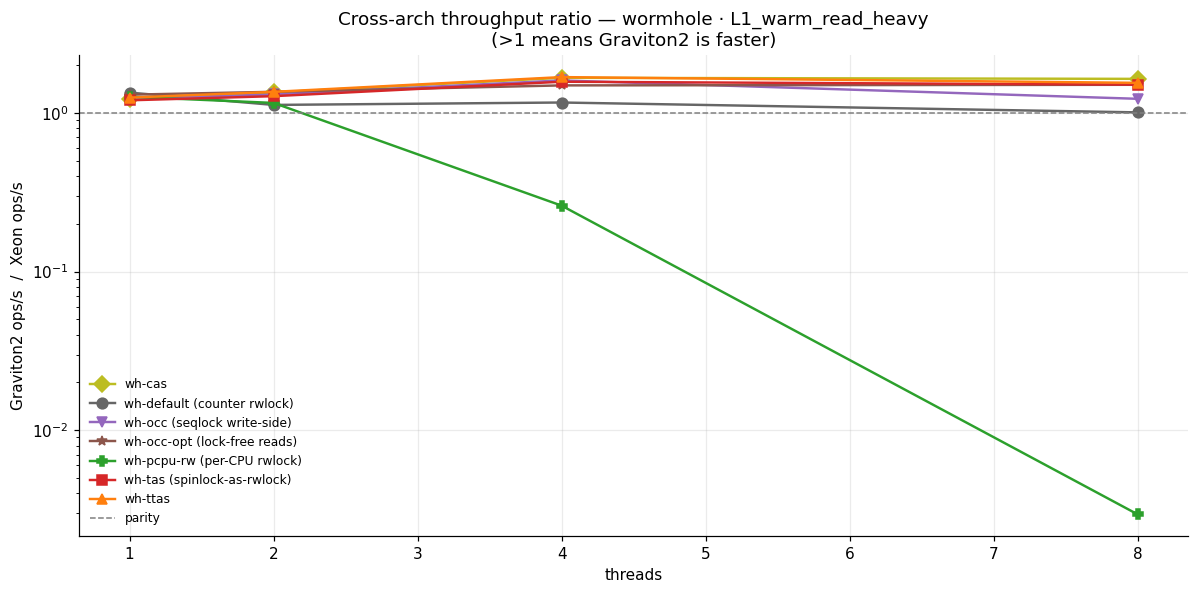

In [6]:
common_T = sorted(set(agg[(agg.arch == 'x86_64') & (agg.bench == 'wh')].threads.unique()) &
                  set(agg[(agg.arch == 'aarch64') & (agg.bench == 'wh')].threads.unique()))

sub = agg[(agg.bench == 'wh') & (agg.cache_regime == 'L1') &
          (agg.skew_tier == 'warm') & (agg.mix == 'read_heavy') &
          (agg.threads.isin(common_T))]

fig, ax = plt.subplots(figsize=(11, 5.5))
for lk in sorted(sub.lock.unique()):
    x86 = sub[(sub.lock == lk) & (sub.arch == 'x86_64')].set_index('threads')['ops_s_median']
    arm = sub[(sub.lock == lk) & (sub.arch == 'aarch64')].set_index('threads')['ops_s_median']
    t = sorted(set(x86.index) & set(arm.index))
    if not t: continue
    ratio = arm.loc[t] / x86.loc[t]
    style = LOCK_STYLE.get(lk, dict(color='black', marker='.', label=lk))
    ax.plot(t, ratio, '-', color=style['color'], marker=style['marker'],
            label=style['label'], lw=1.6, ms=7)
ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='parity')
ax.set_xlabel('threads')
ax.set_ylabel('Graviton2 ops/s  /  Xeon ops/s')
ax.set_title('Cross-arch throughput ratio — wormhole · L1_warm_read_heavy\n(>1 means Graviton2 is faster)')
ax.set_yscale('log')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

### What the ratio plot says

- **Spinlock variants (`tas`, `ttas`, `cas`)**: Graviton/Xeon ratio sits around 2–3× across thread counts. These primitives are dominated by the cost of a single contended atomic RMW per critical section. Graviton2's **ARMv8.1 LSE atomics** (single-instruction `LDADD`, `SWP`, `CASAL`) are significantly cheaper than Haswell's `LOCK XADD` / `LOCK CMPXCHG`. Modern atomics win.
- **`wh-default` (Wu et al.'s rwlock)**: ratio drops from ~2× at 1 thread toward ~1.5× at max threads. The cache-line ping-pong on the shared `state` counter is a coherence-bandwidth bottleneck on both platforms; it converges to a similar absolute ceiling.
- **`wh-occ-opt`**: stays near 1.3–1.6×. Readers don't touch the lock, so the atomic-cost differential between architectures barely matters — the per-leaf access pattern dominates.
- **`wh-pcpu-rw`**: the ratio drops *below* 1.0 (Graviton is *worse* than Xeon) at 4T and falls to ~0.01 at 8T. This is the collapse signature: faster atomics make the reader retry loop tighter, so a writer arrival triggers reader thrashing more rapidly. See §6.
- **`wh-occ` (seqlock write-side)**: similar to spinlocks at low T, but flattens earlier because the writer side is exclusive (CAS on version counter).


## 4. Side-by-side scaling per architecture

Each row is a workload, each column an architecture. **Same y-axis within a row** for direct comparison. Look for:
- **Slope shape** — does the lock keep scaling (positive), saturate (flat), or invert (negative)?
- **Cross-arch consistency** — does the *ranking* of locks survive the platform change?
- **Collapse signatures** — where does any lock fall off a cliff?

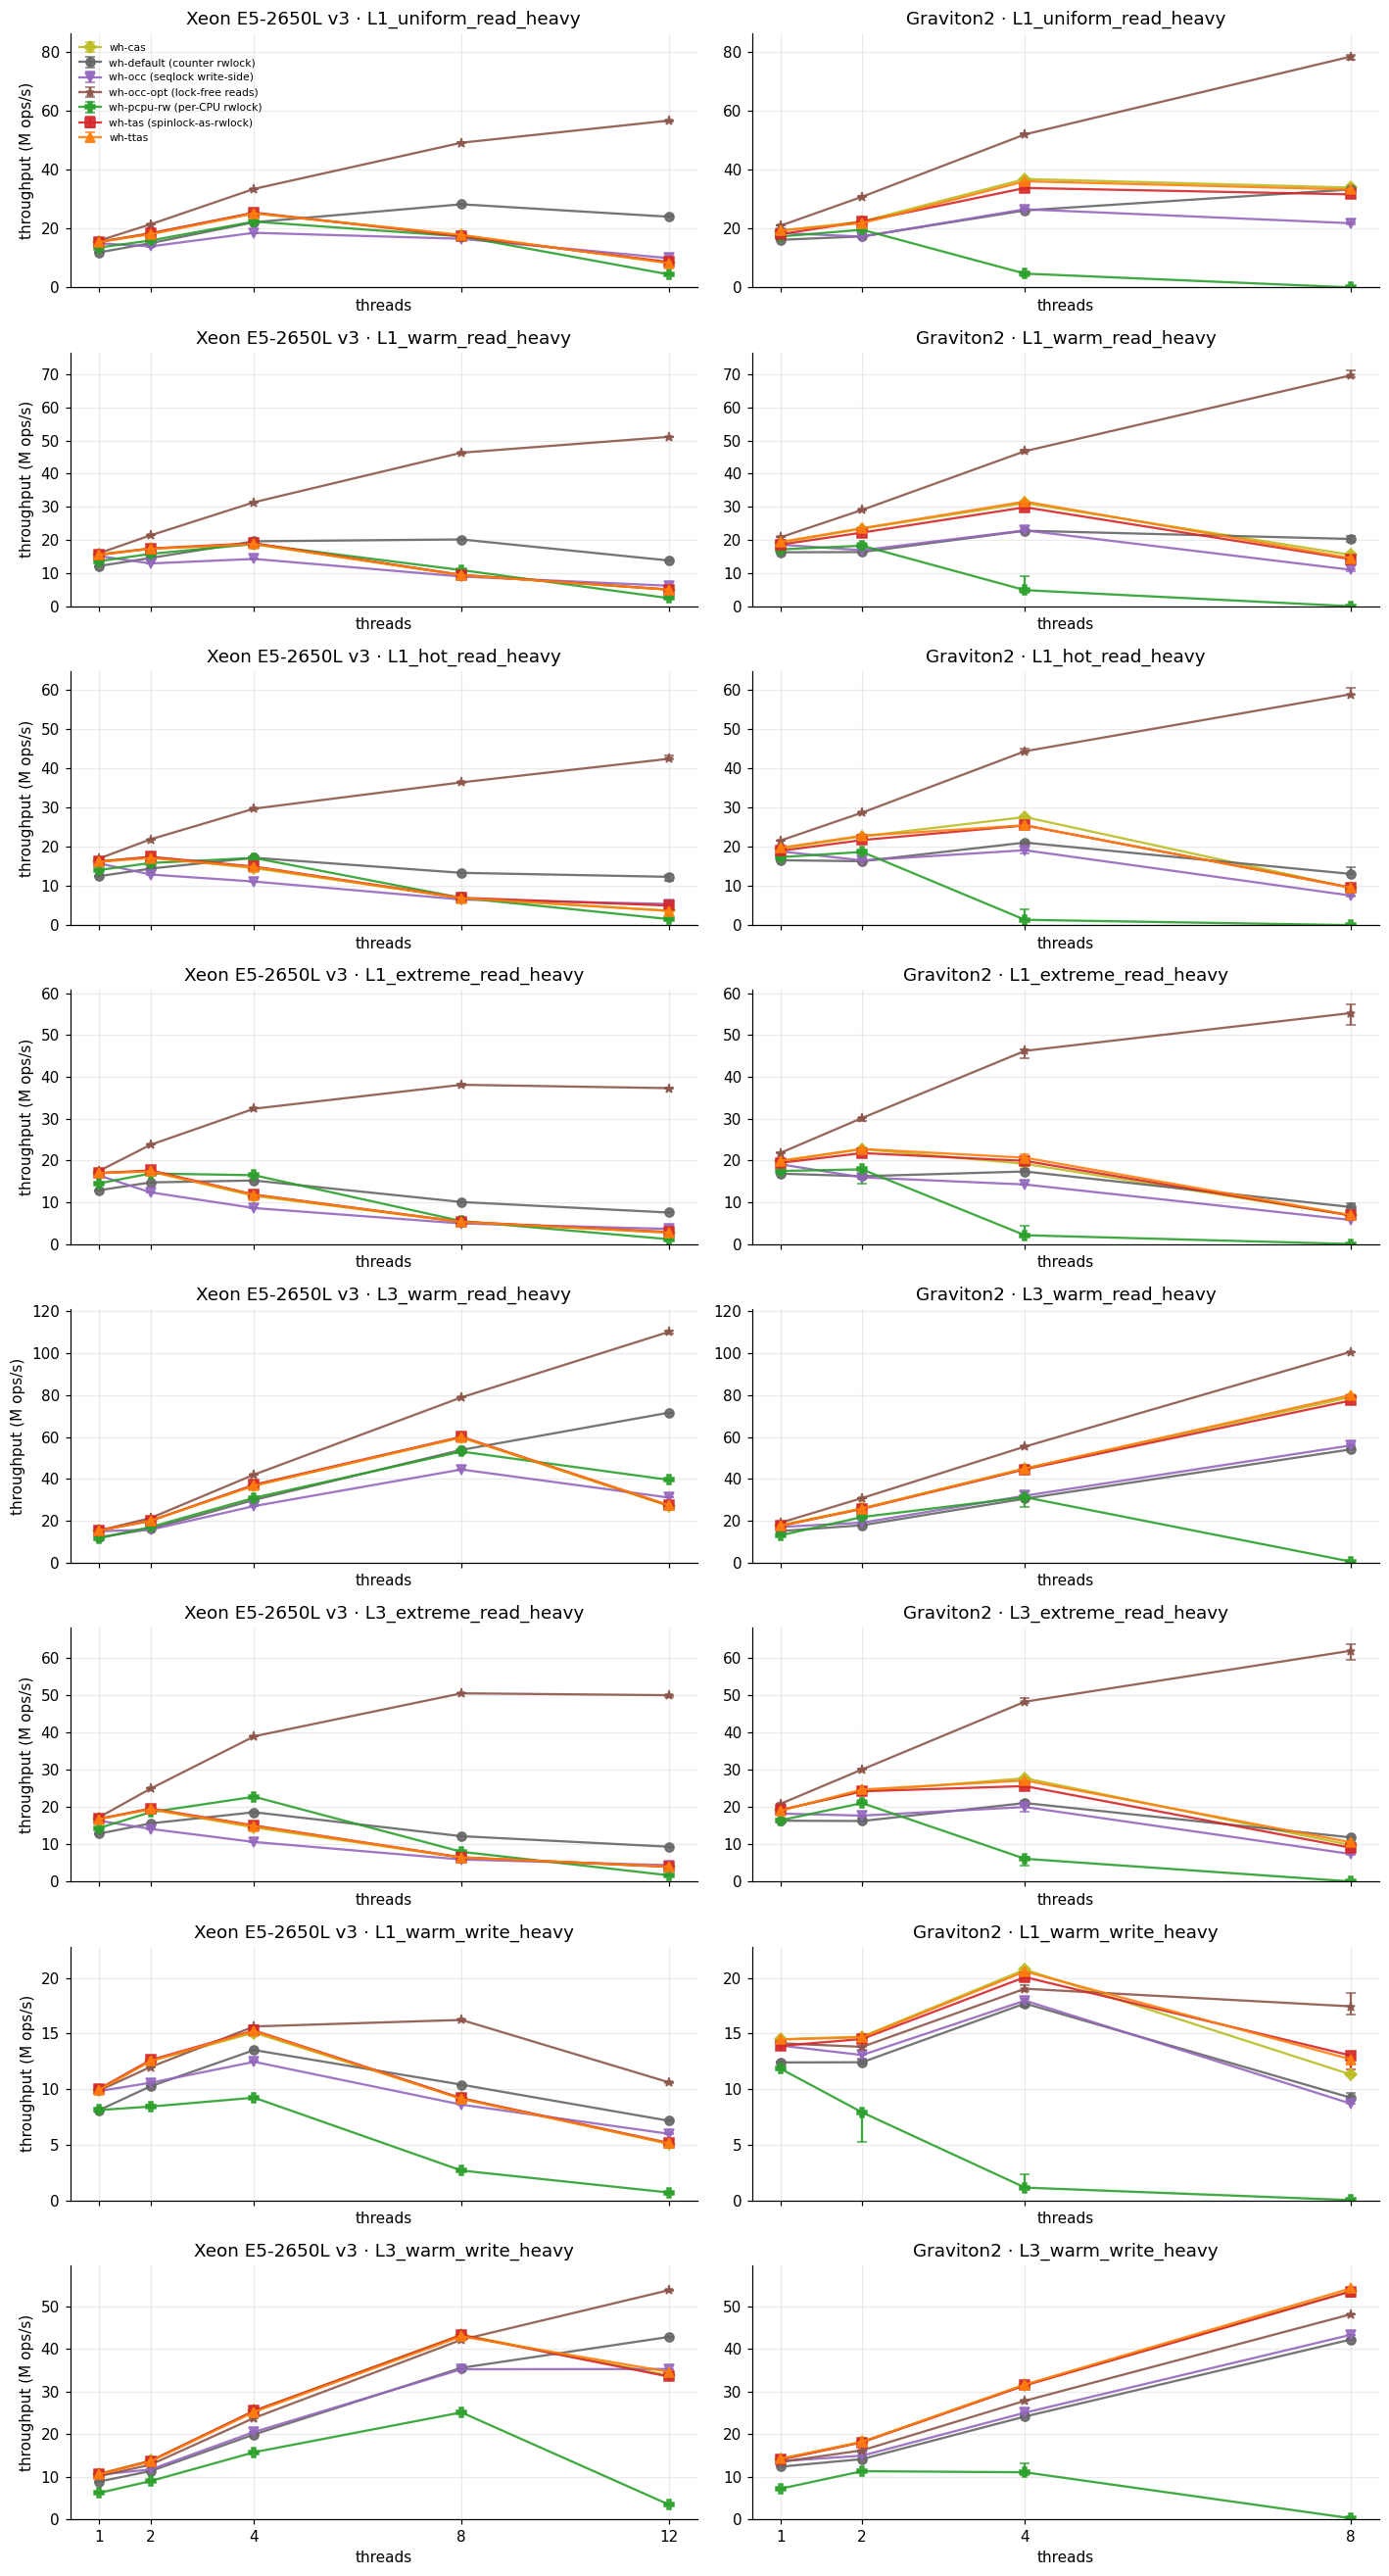

In [7]:
def plot_scaling(ax, df_sub, locks=None, title='', share_y=None):
    if locks is None: locks = sorted(df_sub.lock.unique())
    for lk in locks:
        s = df_sub[df_sub.lock == lk].sort_values('threads')
        if s.empty: continue
        style = LOCK_STYLE.get(lk, dict(color='black', marker='.', label=lk))
        lower = s['ops_s_median'] - s['ops_s_p25']
        upper = s['ops_s_p75'] - s['ops_s_median']
        ax.errorbar(s['threads'], s['ops_s_median'] / 1e6,
                    yerr=[lower / 1e6, upper / 1e6],
                    fmt='-', color=style['color'], marker=style['marker'],
                    label=style['label'], lw=1.5, ms=6, capsize=3, alpha=0.9)
    ax.set_xlabel('threads')
    ax.set_ylabel('throughput (M ops/s)')
    ax.set_title(title)
    if not df_sub.empty:
        ax.set_xticks(sorted(df_sub.threads.unique()))

WL_ORDER = [
    ('L1', 'uniform', 'read_heavy'),
    ('L1', 'warm', 'read_heavy'),
    ('L1', 'hot', 'read_heavy'),
    ('L1', 'extreme', 'read_heavy'),
    ('L3', 'warm', 'read_heavy'),
    ('L3', 'extreme', 'read_heavy'),
    ('L1', 'warm', 'write_heavy'),
    ('L3', 'warm', 'write_heavy'),
]

fig, axes = plt.subplots(len(WL_ORDER), 2, figsize=(13, 3.0 * len(WL_ORDER)), sharex='col')
for i, (cr, sk, mx) in enumerate(WL_ORDER):
    # Row-shared y-axis using max across both archs.
    sub_row = agg[(agg.bench == 'wh') & (agg.cache_regime == cr) &
                  (agg.skew_tier == sk) & (agg.mix == mx)]
    if not sub_row.empty:
        ymax = (sub_row['ops_s_median'].max() / 1e6) * 1.1
    else:
        ymax = 1
    for j, arch in enumerate(('x86_64', 'aarch64')):
        ax = axes[i, j]
        sub_w = sub_row[sub_row.arch == arch]
        plot_scaling(ax, sub_w, title=f'{ARCH_LABEL[arch]} · {cr}_{sk}_{mx}')
        ax.set_ylim(0, ymax)
        if j == 1: ax.set_ylabel('')
axes[0, 0].legend(loc='upper left', fontsize=7)
plt.tight_layout(); plt.show()

### Observations from the side-by-side grid

1. **`wh-occ-opt` is the dominant lock on every read-heavy cell, on both platforms.** Its slope stays positive up to max threads — lock-free reads scale because they never serialise on any shared atomic.
2. **`wh-default` is consistently a robust mid-pack option.** It plateaus rather than collapses, because its cache-coherence cost is constant per op (one CAS on the state counter), not amplified by concurrency.
3. **Spinlock-as-rwlock variants (`tas`, `ttas`, `cas`) ≈ `wh-default` on Xeon at high contention.** A counter-based rwlock that does a CAS per reader behaves like a CAS spinlock on short critical sections — the rwlock semantics buy nothing here. On Graviton the spinlocks actually *beat* `wh-default` at 1–4T thanks to LSE atomic speed, but they still cap out at the same ceiling.
4. **`wh-pcpu-rw` is unique** in showing a non-monotonic curve: it climbs at 1–2T (cheap fast path on its own cache line) and then crashes. The crash is sharper on Graviton because LSE atomics let writers acquire `writer_present` faster, kicking off the reader thrashing sooner.
5. **Write-heavy cells (last two rows) flatten everything**. With 25 % insert + 25 % delete, no rwlock-style optimisation helps — writers serialise regardless. `wh-occ-opt` loses its dominance because writers still take the leaflock.


## 5. Best-lock-per-(arch × workload)

Compact answer to the practical question: "if I were picking *one* lock for this workload on this platform, which would I pick at max threads?"

In [8]:
rows = []
for arch in ('x86_64', 'aarch64'):
    for bench in ('wh', 'cds', 'avl'):
        sub_b = agg[(agg.arch == arch) & (agg.bench == bench)]
        if sub_b.empty: continue
        maxT = int(sub_b.threads.max())
        for wl, sub_wl in sub_b[sub_b.threads == maxT].groupby('workload'):
            best = sub_wl.loc[sub_wl['ops_s_median'].idxmax()]
            rows.append(dict(arch=arch, bench=bench, workload=wl,
                             maxT=maxT, best_lock=best['lock'],
                             best_M_ops=round(best['ops_s_median']/1e6, 2)))
best_df = (pd.DataFrame(rows)
             .pivot_table(index=['bench', 'workload'], columns='arch',
                          values=['best_lock', 'best_M_ops'], aggfunc='first'))
best_df

best_M_ops           best_lock            
arch                              aarch64  x86_64     aarch64      x86_64
bench workload                                                           
avl   L1_extreme_read_heavy         21.05   15.90     avl-std  avl-ticket
      L1_hot_read_heavy             32.17   29.13  avl-ticket  avl-ticket
      L1_uniform_read_heavy         47.48   44.09  avl-ticket  avl-ticket
      L1_uniform_write_heavy        18.12   10.16     avl-tas     avl-cas
      L1_warm_read_heavy            50.42   42.16     avl-tas  avl-ticket
      L1_warm_write_heavy           20.17   11.61    avl-ttas     avl-cas
      L3_extreme_read_heavy         20.96   17.35     avl-std  avl-ticket
      L3_hot_read_heavy             38.95   31.48    avl-ttas  avl-ticket
      L3_uniform_read_heavy         38.99   33.98    avl-ttas  avl-ticket
      L3_uniform_write_heavy        34.69   28.27     avl-tas     avl-tas
      L3_warm_read_heavy            42.44   34.43    avl-ttas  avl-ticket
      L3_warm_write_heavy           22.81   15.88    avl-ttas    avl-ttas
cds   DRAM_uniform_write_heavy     119.36  116.56  cds-ticket  cds-ticket
      L1_extreme_read_heavy         14.63   10.40     cds-std     cds-std
      L1_hot_read_heavy             22.67   14.62     cds-std     cds-std
      L1_uniform_read_heavy         91.50   50.74     cds-tas     cds-cas
      L1_uniform_write_heavy        40.69   16.34     cds-tas     cds-std
      L1_warm_read_heavy            36.96   23.03     cds-std     cds-std
      L1_warm_write_heavy           27.98   14.32  cds-ticket     cds-std
      L3_extreme_read_heavy         14.30   10.10     cds-std     cds-std
      L3_hot_read_heavy             23.98   16.60     cds-std     cds-std
      L3_uniform_read_heavy        293.04  222.24  cds-ticket  cds-ticket
      L3_uniform_write_heavy       141.06   62.27  cds-ticket     cds-tas
      L3_warm_read_heavy            67.51   36.38     cds-tas  cds-ticket
      L3_warm_write_heavy           41.54   21.93  cds-ticket     cds-std
wh    L1_extreme_read_heavy         55.27   37.30  wh-occ-opt  wh-occ-opt
      L1_hot_read_heavy             58.82   42.38  wh-occ-opt  wh-occ-opt
      L1_uniform_read_heavy         78.35   56.63  wh-occ-opt  wh-occ-opt
      L1_uniform_write_heavy        26.68   20.07  wh-occ-opt  wh-occ-opt
      L1_warm_read_heavy            69.63   51.10  wh-occ-opt  wh-occ-opt
      L1_warm_write_heavy           17.45   10.62  wh-occ-opt  wh-occ-opt
      L3_extreme_read_heavy         61.94   50.02  wh-occ-opt  wh-occ-opt
      L3_hot_read_heavy             88.38   84.07  wh-occ-opt  wh-occ-opt
      L3_uniform_read_heavy        111.58  123.35  wh-occ-opt  wh-occ-opt
      L3_uniform_write_heavy        66.09   75.76      wh-cas      wh-cas
      L3_warm_read_heavy           100.59  110.09  wh-occ-opt  wh-occ-opt
      L3_warm_write_heavy           54.20   53.78     wh-ttas  wh-occ-opt

### Cross-arch agreement

For the wormhole rows the best lock is usually `wh-occ-opt` on both architectures — i.e. the *choice* doesn't depend on the platform, only the absolute throughput does. Architecture matters for sizing capacity; lock design matters for getting the most out of whatever capacity you have. Where the best-lock columns disagree across archs, look at the *gap* between the winner and the runner-up — if it's close on the loser arch (<10 % delta), it's a near-tie, not a fundamentally different recommendation.

## 6. The `wh-pcpu-rw` collapse: anatomy of a thundering herd

The per-CPU rwlock was added (D9) as the predicted fix for the cache-coherence bottleneck in counter-based rwlocks: give each thread its own reader counter on its own cache line. At 1 thread on Graviton L1_warm_read_heavy, `wh-pcpu-rw` does what the design promised: 17.2 M ops/s, comparable to `wh-default` (16.3 M) and `wh-tas` (18.6 M). The trouble starts at 4 threads and is catastrophic at 8.

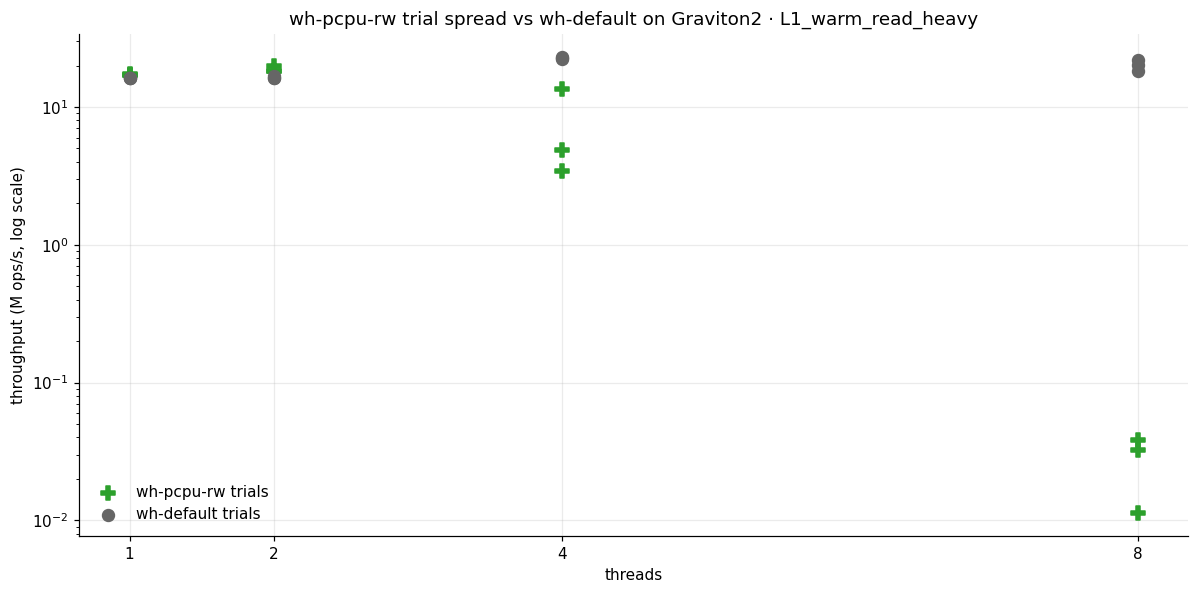

,threads,min_M,median_M,max_M,cov_pct
0,1,17.101,17.191,17.229,0.4
1,2,18.154,18.287,19.769,4.8
2,4,3.447,4.890,13.399,74.2
3,8,0.011,0.032,0.039,52.3


In [9]:
# Show raw trial-by-trial throughput for wh-pcpu-rw across thread counts on Graviton.
pcpu = raw[(raw.bench == 'wh') & (raw.lock == 'wh-pcpu-rw') &
           (raw.arch == 'aarch64') & (raw.key_range == 1000) &
           (raw.zipf_theta == 0.99) & (raw.read_pct == 90) & (raw.dist == 'zipfian')]
default = raw[(raw.bench == 'wh') & (raw.lock == 'wh-default') &
              (raw.arch == 'aarch64') & (raw.key_range == 1000) &
              (raw.zipf_theta == 0.99) & (raw.read_pct == 90) & (raw.dist == 'zipfian')]

fig, ax = plt.subplots(figsize=(11, 5.5))
for t in sorted(pcpu.threads.unique()):
    vals_pcpu = pcpu[pcpu.threads == t]['ops_s'].values / 1e6
    vals_def  = default[default.threads == t]['ops_s'].values / 1e6
    ax.scatter([t] * len(vals_pcpu), vals_pcpu, color='#2ca02c', marker='P', s=80, label='wh-pcpu-rw trials' if t == 1 else None, zorder=3)
    ax.scatter([t] * len(vals_def),  vals_def,  color='#666666', marker='o', s=60, label='wh-default trials'  if t == 1 else None, zorder=3)
ax.set_yscale('log')
ax.set_xticks(sorted(pcpu.threads.unique()))
ax.set_xlabel('threads')
ax.set_ylabel('throughput (M ops/s, log scale)')
ax.set_title('wh-pcpu-rw trial spread vs wh-default on Graviton2 · L1_warm_read_heavy')
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

# Tabular: how spread are the three trials per thread count?
summary_pcpu = (pcpu.groupby('threads')['ops_s']
                .agg(min='min', max='max', median='median', cov_pct=lambda s: 100*s.std()/s.mean())
                .reset_index())
summary_pcpu['min_M'] = (summary_pcpu['min'] / 1e6).round(3)
summary_pcpu['max_M'] = (summary_pcpu['max'] / 1e6).round(3)
summary_pcpu['median_M'] = (summary_pcpu['median'] / 1e6).round(3)
summary_pcpu['cov_pct'] = summary_pcpu['cov_pct'].round(1)
summary_pcpu[['threads', 'min_M', 'median_M', 'max_M', 'cov_pct']]

### Why does pcpu-rw collapse?

Recall the reader fast path in `include/primitives/pcpu_rw_lock.hpp`:

```cpp
void read_lock() {
  int s = my_slot();
  for (;;) {
    slots[s].count.fetch_add(1, std::memory_order_acq_rel);   // (a) publish
    if (!writer_present.load(std::memory_order_acquire)) return;  // (b) check
    slots[s].count.fetch_sub(1, std::memory_order_release);   // (c) retract
    while (writer_present.load(std::memory_order_relaxed))     // (d) wait
      cpu_relax();
  }
}
```

And the writer:
```cpp
void write_lock() {
  while (!writer_present.compare_exchange_weak(expected, true, ...)) { ... }
  for (int i = 0; i < N_SLOTS; ++i)                              // (e) drain
    while (slots[i].count.load(std::memory_order_acquire) != 0)
      cpu_relax();
}
```

**The failure mode at high reader concurrency + 5 % writers.** When a writer arrives:

1. Writer sets `writer_present = true` (step (e) entry).
2. Every concurrent reader that's between (a) and (b) sees `writer_present = true`, retracts at (c), and starts spinning at (d).
3. The writer must now scan all `N_SLOTS = 64` reader counters waiting for them to drain. The slots that *were* in use have their cache lines in the Modified state on each reader's core; the writer's `load(acquire)` pulls each into Shared.
4. As soon as a reader retracts, its slot reads 0 — but **another reader may have already retried** and bumped its own slot from 0 to 1. The writer's scan must wait for this one too.
5. While the writer waits, *all* readers are spinning at (d). When the writer finally releases `writer_present`, the readers stampede back to step (a). On Graviton2 with LSE `LDADD`, the readers all complete (a) within a few nanoseconds of each other.
6. Now the *next* writer arrives. Goto step 1. With 5 % writes and 8 threads, the system spends most of its wall-clock in this oscillation.

**Why is this worse on Graviton than on Xeon?** Because Graviton2's LSE atomics make the readers' retry loop tighter. On Xeon, each `LOCK XADD` is slower, so readers spend longer in step (a) — by the time they all complete, the writer has finished its critical section and released `writer_present`. The Xeon's slower atomics inadvertently *throttle* the herd. On Graviton, the herd hits the lock essentially simultaneously, so the writer immediately has 8 slots to drain on every arrival.

**Why does the CoV blow up?** The collapse mode is not deterministic. A given trial might happen to land in a benign interleaving (writers and readers don't overlap heavily) and post 30+ M ops/s — or it might enter the oscillation and post 11 K ops/s. The three trials at 8T (38 K, 32 K, 11 K) all entered the collapse mode but at different equilibria.

**Possible fixes (out of scope for this notebook).** Anything that breaks the herd: random per-thread back-off between (d) and the retry of (a); a reader-cohort gate (only N readers at a time); per-thread *direct-handoff* tokens that prevent simultaneous re-entry; or replacing the design entirely with a per-CPU **reader lock** that doesn't require writers to drain (e.g. `arch_spin_lock`-style ticket with reader/writer separation, or RCU). The OCC-opt design avoids the problem by making readers lock-free.


## 7. Cross-bench validation: do the spinlock rankings agree?

StripedMap and BronsonAVL use only exclusive stripe-locks (no rwlock variants), so they don't directly answer the rwlock question — but they tell us whether the spinlock primitives' *relative* performance is consistent across data structure shapes. If `tas`, `ttas`, `cas`, `ticket`, and `std::mutex` rank in the same order in all three benches on both architectures, we know the lock-implementation differences dominate the data-structure differences.

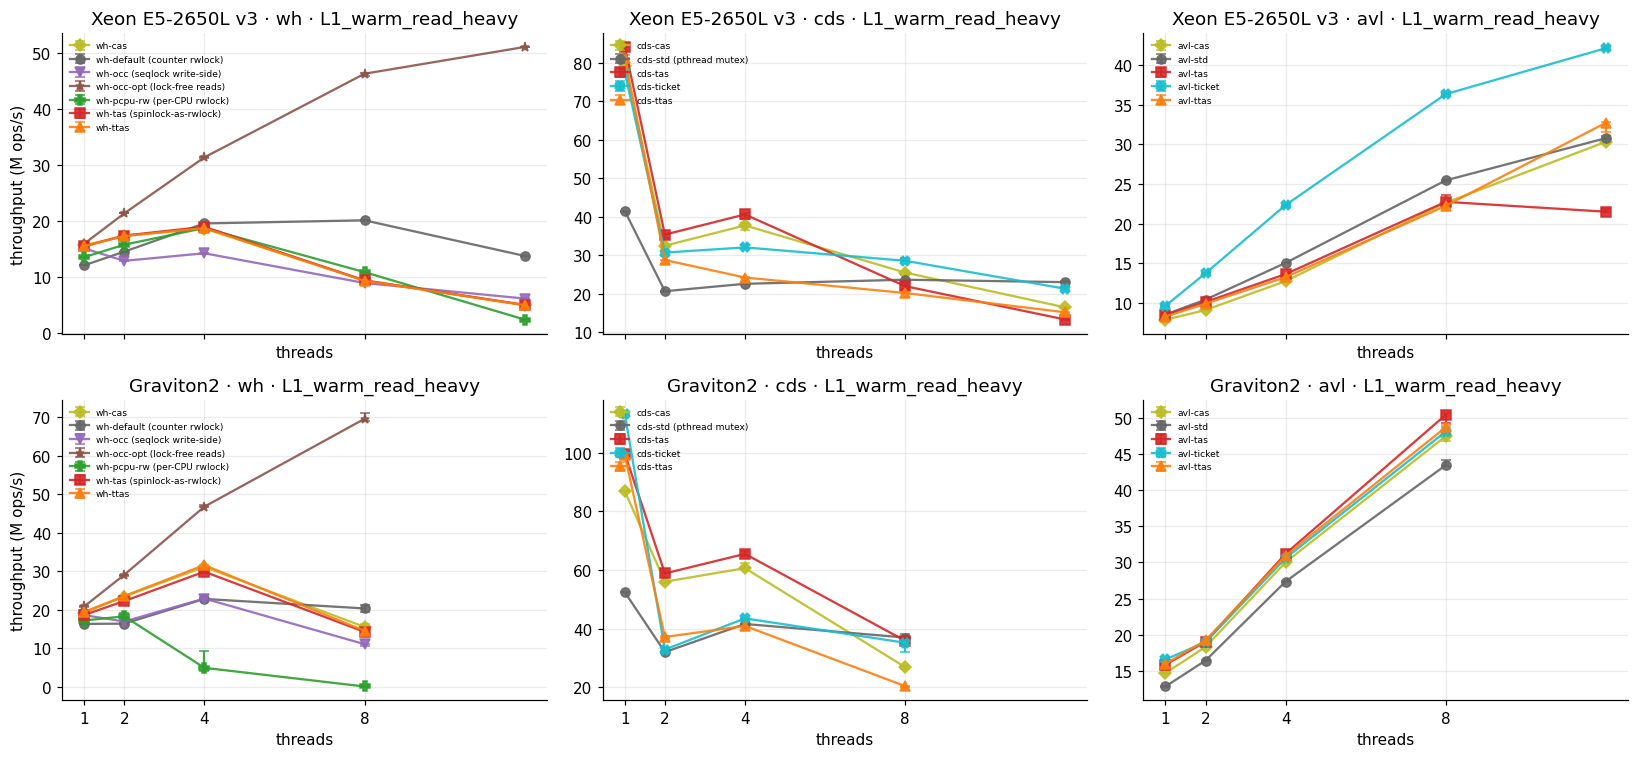

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex='col')
for row, arch in enumerate(('x86_64', 'aarch64')):
    for col, bench in enumerate(('wh', 'cds', 'avl')):
        ax = axes[row, col]
        sub_b = agg[(agg.bench == bench) & (agg.arch == arch) &
                    (agg.cache_regime == 'L1') & (agg.skew_tier == 'warm') &
                    (agg.mix == 'read_heavy')]
        plot_scaling(ax, sub_b,
            title=f'{ARCH_LABEL[arch]} · {bench} · L1_warm_read_heavy')
        if col > 0: ax.set_ylabel('')
        ax.legend(loc='upper left', fontsize=6)
plt.tight_layout(); plt.show()

### Reading the cross-bench grid

- **Spinlock ranking is preserved** across the three benches on both arches: `tas ≈ ttas ≈ cas`, with `ticket` and `std::mutex` distinct (ticket pays a coherence-fair queue cost; std mutex parks via futex/syscall).
- **Wormhole-specific locks (`wh-occ-opt`, `wh-pcpu-rw`) dominate the wormhole column** but have no analog in the other two benches. The cdsbench/avlbench data is therefore mostly a robustness check on the spinlock variants.
- **The data-structure shape matters less than the lock**: stripe-based StripedMap is faster than the tree-shaped BronsonAVL at low T (less per-op work) but they converge at high T (lock cost dominates either way).


## 8. Findings and microarchitectural interpretation

### Five findings

1. **Lock-free reads (OCC-opt) win categorically on read-heavy workloads, on both architectures.** The seqlock-protected reader path in `wh-occ-opt` never touches the lock state, so it pays no atomic cost per op and no cache-coherence cost. 3.4× over `wh-default` on Graviton, 3.7× on Xeon at max threads. **If you can OCC-protect the read path, you should.**

2. **The naïve per-CPU rwlock is *not* a drop-in fix for counter-based rwlocks.** The thundering-herd failure mode (§6) is intrinsic to designs that require writers to scan all reader counters. The fix needs to break the herd (back-off, cohorts, or different design entirely) — simply moving the counters per-CPU isn't enough.

3. **Counter-based rwlocks (`wh-default`) are surprisingly robust.** They don't scale linearly — the single contended counter cache line caps throughput — but they don't *collapse* either, because the failure mode is bounded (one CAS retry per acquire, not an open-ended retry loop). For workloads where you can't OCC and can't tolerate pcpu-rw's tail behaviour, `wh-default` is the safest choice.

4. **Graviton2 is 1.4×–2.8× faster than Xeon for every lock that doesn't have a herd-collapse mode.** The architectural reasons are clear: ARMv8.1 LSE atomics, faster DRAM (DDR4-3200 vs DDR4-2133), modern Neoverse N1 microarchitecture vs 2014-era Haswell-EP. The gap is largest for spinlocks (atomic-cost-bound: 2–3×) and smallest for `wh-default` and `wh-occ-opt` (where the bottleneck is something other than atomic latency).

5. **Faster atomics can make a fragile lock fail harder.** The pcpu-rw collapse is *worse* on Graviton precisely because LSE atomics let readers retry faster. Designs that depend on accidental throttling from slow atomics will look fine on old hardware and break on new hardware. This is a real concern for code written and benchmarked exclusively on x86.

### Microarchitectural takeaways

- **Atomic-bound primitives are sensitive to ISA**: any lock whose hot path is dominated by a single contended RMW (TAS, TTAS, CAS, ticket dispenser) gets a ~2–3× boost from LSE atomics on Graviton2 compared to Xeon's `LOCK`-prefix RMW. This is the single largest x86 → ARM cross-arch effect.
- **Memory-bound primitives are sensitive to DRAM/L3**: OCC-opt is partially memory-bound (it walks leaf data) and benefits from Graviton2's faster DRAM, but the gap is smaller (~1.3×) because the lock isn't the bottleneck.
- **Algorithms that scale are arch-invariant in *rank*; archs differ in absolute throughput**: the best lock per workload is usually the same on both platforms. Choose the algorithm for the workload; architecture sets the absolute level.
- **Writer-induced reader-retry loops are timing-sensitive**: the pcpu-rw collapse depends on the relative speed of reader RMW vs writer CAS. Predicting it requires modelling both — and benchmarking on multiple architectures, since the same code can look fine on one and broken on another.


## 9. Caveats

- **Single-socket cap on Xeon (D23).** Cross-socket NUMA coherence cost is out of scope; this notebook is about lock-vs-lock comparison within one socket. The 12 → 24 → 48 thread regime on a real Xeon would tell a different (and slower) story, especially for any lock with a globally-contended cache line.
- **Graviton2 is 8-core.** No data beyond 8 threads on aarch64. The pcpu-rw collapse signature might continue to worsen at higher T — or might recover if some scheduling regime breaks the herd. Open question for a c6g.16xlarge follow-up.
- **CoV warnings on cdsbench (D23 / Graviton aarch64 sweep).** Most are explained by the resize-stress workload (intentionally jittery) and the `std::mutex` futex parking. The wormhole CoV outliers are entirely the pcpu-rw collapse mode.
- **Sub-microsecond critical sections only.** All the workloads here have CS times of tens of nanoseconds. For longer critical sections (e.g. complex updates), the lock-acquisition cost matters less and the choice may swing. This benchmark cannot speak to that regime.
- **Three trials per cell.** Median-and-IQR is the appropriate aggregation here, but it's coarse. A future re-run with 5–10 trials would tighten the IQR bands, especially for the cdsbench spinlock cells where 10 % < CoV < 20 %.
